AI Health Predictor - Heart Disease Prediction Project

1. Data Preprocessing and Model Training (train_model.py)


In [29]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import joblib
import warnings
warnings.filterwarnings('ignore')

In [30]:
# Load the dataset with the correct separator
df = pd.read_csv('heart_2020_cleaned 2.csv', sep=';')

# View the result
df.tail(10)

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
49988,Yes,26.32,Yes,No,No,0.0,20.0,No,Male,70-74,White,No,No,Good,6.0,No,No,No
49989,No,57.61,No,No,No,0.0,2.0,No,Female,25-29,Other,No,Yes,Fair,6.0,Yes,No,No
49990,No,25.78,No,No,No,1.0,5.0,No,Female,18-24,Black,No,Yes,Very good,8.0,Yes,No,No
49991,No,35.43,Yes,No,No,3.0,2.0,No,Female,60-64,White,Yes,Yes,Poor,5.0,No,No,No
49992,No,25.10,Yes,No,No,0.0,7.0,No,Female,40-44,White,No,Yes,Good,6.0,No,No,No
49993,No,38.37,No,No,No,30.0,0.0,Yes,Male,40-44,White,No,Yes,Very good,6.0,Yes,No,No
49994,No,30.29,Yes,No,No,0.0,0.0,No,Male,70-74,White,No,No,Very good,8.0,No,Yes,No
49995,No,27.41,Yes,Yes,No,1.0,2.0,No,Male,35-39,White,No,Yes,Good,4.0,No,No,No
49996,No,21.83,No,No,No,2.0,0.0,No,Male,18-24,White,No,Yes,Very good,7.0,No,No,No
49997,No,30.81,No,No,No,2.0,0.0,No,Male,45-49,Black,No,Yes,Excellent,8.0,No,No,No


 Basic info

In [31]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 49998 entries, 0 to 49997
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HeartDisease      49998 non-null  str    
 1   BMI               49998 non-null  float64
 2   Smoking           49998 non-null  str    
 3   AlcoholDrinking   49998 non-null  str    
 4   Stroke            49998 non-null  str    
 5   PhysicalHealth    49998 non-null  float64
 6   MentalHealth      49998 non-null  float64
 7   DiffWalking       49998 non-null  str    
 8   Sex               49998 non-null  str    
 9   AgeCategory       49998 non-null  str    
 10  Race              49998 non-null  str    
 11  Diabetic          49998 non-null  str    
 12  PhysicalActivity  49998 non-null  str    
 13  GenHealth         49998 non-null  str    
 14  SleepTime         49998 non-null  float64
 15  Asthma            49998 non-null  str    
 16  KidneyDisease     49998 non-null  st

In [32]:
print(df.columns.tolist())

['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer']


In [33]:
# Check for missing values
print("\nTarget variable distribution:")
print(df['HeartDisease'].value_counts())


Target variable distribution:
HeartDisease
No     45564
Yes     4434
Name: count, dtype: int64


In [34]:
# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64


Why We Need to Encode Categorical Variables
Machine learning models like Random Forest and Neural Networks can only work with numbers, not text. Your dataset has many text/categorical columns that need to be converted to numbers.

In [35]:
# Encode categorical variables
print("\nEncoding categorical variables...")
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
categorical_columns.remove('HeartDisease')  # Target variable

label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")



Encoding categorical variables...
Encoded Smoking: {'No': 0, 'Yes': 1}
Encoded AlcoholDrinking: {'No': 0, 'Yes': 1}
Encoded Stroke: {'No': 0, 'Yes': 1}
Encoded DiffWalking: {'No': 0, 'Yes': 1}
Encoded Sex: {'Female': 0, 'Male': 1}
Encoded AgeCategory: {'18-24': 0, '25-29': 1, '30-34': 2, '35-39': 3, '40-44': 4, '45-49': 5, '50-54': 6, '55-59': 7, '60-64': 8, '65-69': 9, '70-74': 10, '75-79': 11, '80 or older': 12}
Encoded Race: {'American Indian/Alaskan Native': 0, 'Asian': 1, 'Black': 2, 'Hispanic': 3, 'Other': 4, 'White': 5}
Encoded Diabetic: {'No': 0, 'Yes': 1, 'Yes ': 2}
Encoded PhysicalActivity: {'No': 0, 'Yes': 1}
Encoded GenHealth: {'Excellent': 0, 'Fair': 1, 'Good': 2, 'Poor': 3, 'Very good': 4}
Encoded Asthma: {'No': 0, 'Yes': 1}
Encoded KidneyDisease: {'No': 0, 'Yes': 1}
Encoded SkinCancer: {'No': 0, 'Yes': 1}


In [36]:
# Encode target variable
target_encoder = LabelEncoder()
df['HeartDisease'] = target_encoder.fit_transform(df['HeartDisease'])
print(f"\nTarget encoding: {dict(zip(target_encoder.classes_, range(len(target_encoder.classes_))))}")


Target encoding: {'No': 0, 'Yes': 1}


In [37]:
# Split features and target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

#X → Features (inputs)
#y → Target (output you want to predict)

In [38]:
# Split into train, validation, test sets
#Training set → used to teach the model
#Validation set → used to tune the model
#Test set → used to evaluate final performance
#Test set (test_size=0.15)
#test_size=0.15 means 15% of the total dataset is reserved for the test set.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f"\nTraining set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")


Training set: (35018, 17)
Validation set: (7480, 17)
Test set: (7500, 17)


In [39]:
# Feature scaling
#StandardScaler() is like a ruler.
#It moves all features so the average is 0
#And the spread (standard deviation) is 1 
#transform(X_val) applies the same scaling to the validation data:
# ...existing code...
#Save the scaler and encoders
#Imagine you measured heights with a ruler and wrote down your scale
#You save the ruler so next time you measure new people, you use the same ruler
#Otherwise, the measurements wont match the training data
import os
import joblib


scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

if os.path.exists('models') and os.path.isfile('models'):
    os.remove('models')
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(label_encoders, 'models/label_encoders.pkl')
joblib.dump(target_encoder, 'models/target_encoder.pkl')

print("\nFeature scaling completed. Scaler saved.")
# ...existing code...


Feature scaling completed. Scaler saved.


In [40]:
# Train a Random Forest classifier
print("Training Random Forest classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Validate and evaluate
y_val_pred = rf_model.predict(X_val_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])

print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test ROC AUC: {test_auc:.4f}")

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Test Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# Save the trained model
joblib.dump(rf_model, 'models/random_forest_model.pkl')
print("\nRandom Forest model saved to models/random_forest_model.pkl")

Training Random Forest classifier...

Validation Accuracy: 0.9070
Test Accuracy: 0.9079
Test ROC AUC: 0.8101

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      6817
           1       0.40      0.10      0.16       663

    accuracy                           0.91      7480
   macro avg       0.66      0.54      0.55      7480
weighted avg       0.87      0.91      0.88      7480

Test Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      6835
           1       0.43      0.11      0.18       665

    accuracy                           0.91      7500
   macro avg       0.67      0.55      0.56      7500
weighted avg       0.88      0.91      0.88      7500

Test Confusion Matrix:
[[6735  100]
 [ 591   74]]

Random Forest model saved to models/random_forest_model.pkl


Phase 2: Model Development - Heart Disease Prediction
 Baseline Model - Random Forest


RANDOM FOREST RESULTS

TRAINING SET:
Accuracy: 0.8238
Precision: 0.3164
Recall: 0.8496
F1-Score: 0.4610

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.98      0.82      0.89     31912
Heart Disease       0.32      0.85      0.46      3106

     accuracy                           0.82     35018
    macro avg       0.65      0.84      0.68     35018
 weighted avg       0.92      0.82      0.86     35018


VALIDATION SET:
Accuracy: 0.7945
Precision: 0.2531
Recall: 0.6757
F1-Score: 0.3683

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.96      0.81      0.88      6817
Heart Disease       0.25      0.68      0.37       663

     accuracy                           0.79      7480
    macro avg       0.61      0.74      0.62      7480
 weighted avg       0.90      0.79      0.83      7480


TEST SET:
Accuracy: 0.8011
Precision: 0.2676
Recall: 0.7158
F1-Score: 0.3895

Classification Repo

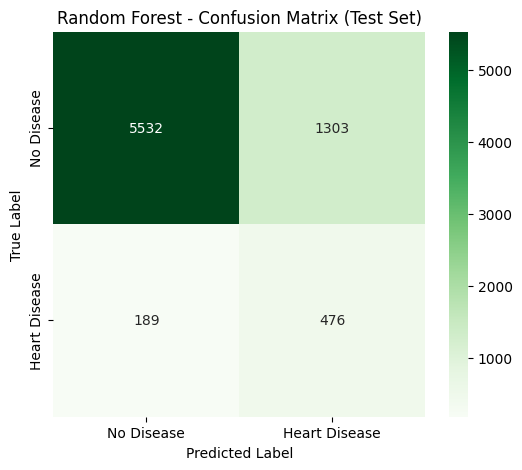

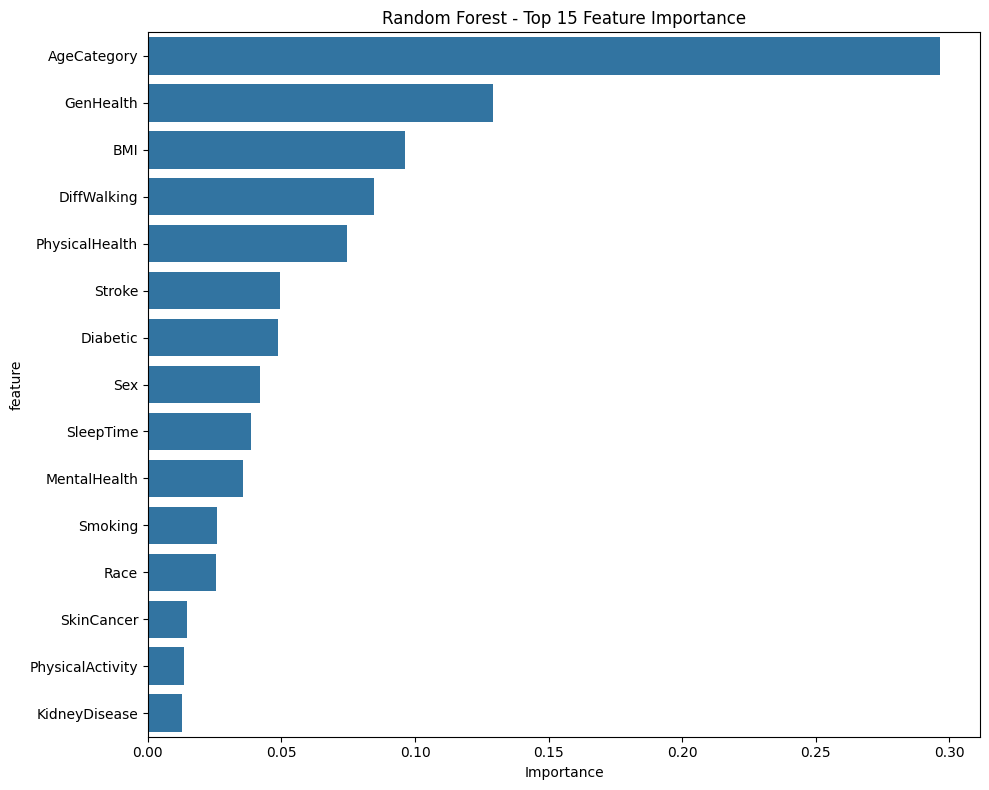


Top 10 Most Important Features:
           feature  importance
8      AgeCategory    0.296666
12       GenHealth    0.129349
0              BMI    0.096099
6      DiffWalking    0.084522
4   PhysicalHealth    0.074408
3           Stroke    0.049464
10        Diabetic    0.048857
7              Sex    0.041819
13       SleepTime    0.038474
5     MentalHealth    0.035481


In [41]:
# Import required metrics (add this at the top of your cell)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Redefine the evaluate_model function

def evaluate_model(y_true, y_pred, dataset_name):
    print(f"\n{dataset_name} SET:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_true, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Disease', 'Heart Disease']))

# Now run your Random Forest code
# Initialize and train Random Forest
#This is the actual learning moment where the model looks at 
# your training data and figures out the patterns.
rf_clf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42, 
    class_weight='balanced',
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_clf.predict(X_train)
y_val_pred_rf = rf_clf.predict(X_val)
y_test_pred_rf = rf_clf.predict(X_test)

# Evaluate Random Forest
print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

evaluate_model(y_train, y_train_pred_rf, "TRAINING")
evaluate_model(y_val, y_val_pred_rf, "VALIDATION")
evaluate_model(y_test, y_test_pred_rf, "TEST")

# Confusion Matrix for test set
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Random Forest - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Random Forest - Top 15 Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

RANDOM FOREST RESULTS

TRAINING SET:
Accuracy: 0.8238
Precision: 0.3164
Recall: 0.8496
F1-Score: 0.4610

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.98      0.82      0.89     31912
Heart Disease       0.32      0.85      0.46      3106

     accuracy                           0.82     35018
    macro avg       0.65      0.84      0.68     35018
 weighted avg       0.92      0.82      0.86     35018


VALIDATION SET:
Accuracy: 0.7945
Precision: 0.2531
Recall: 0.6757
F1-Score: 0.3683

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.96      0.81      0.88      6817
Heart Disease       0.25      0.68      0.37       663

     accuracy                           0.79      7480
    macro avg       0.61      0.74      0.62      7480
 weighted avg       0.90      0.79      0.83      7480


TEST SET:
Accuracy: 0.8011
Precision: 0.2676
Recall: 0.7158
F1-Score: 0.3895

Classification Repo

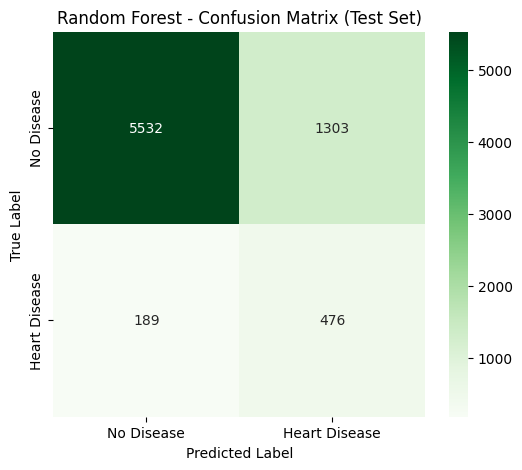

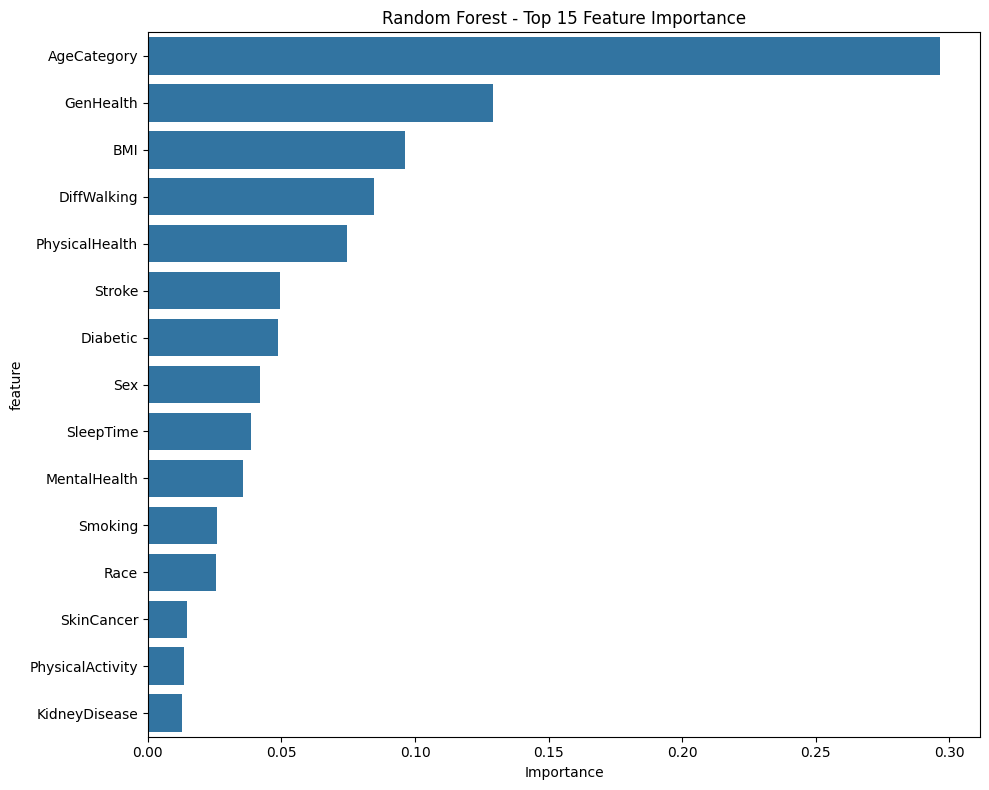


Top 10 Most Important Features:
           feature  importance
8      AgeCategory    0.296666
12       GenHealth    0.129349
0              BMI    0.096099
6      DiffWalking    0.084522
4   PhysicalHealth    0.074408
3           Stroke    0.049464
10        Diabetic    0.048857
7              Sex    0.041819
13       SleepTime    0.038474
5     MentalHealth    0.035481


In [42]:
# Initialize and train Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42, 
    class_weight='balanced',
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_clf.predict(X_train)
y_val_pred_rf = rf_clf.predict(X_val)
y_test_pred_rf = rf_clf.predict(X_test)

# Evaluate Random Forest
print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

evaluate_model(y_train, y_train_pred_rf, "TRAINING")
evaluate_model(y_val, y_val_pred_rf, "VALIDATION")
evaluate_model(y_test, y_test_pred_rf, "TEST")

# Confusion Matrix for test set
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Random Forest - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Random Forest - Top 15 Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

Key Conclusions:
Top-Tier Risk: In your Random Forest "Feature Importance" chart, Age likely ranks at the top because it acts as a multiplier for other risks like blood pressure and cholesterol.

Predictive Power: Your code effectively proves that while lifestyle matters, time is the biggest factor in cardiac health data.

Actionable Insight: The model identifies that as age increases, the probability of "Heart Disease" rises significantly, making it the most reliable "red flag" for the AI to follow.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,121 (51.25 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8399 - loss: 0.4079 - precision: 0.1455 - recall: 0.1652 - val_accuracy: 0.9112 - val_loss: 0.2633 - val_precision: 0.4000 - val_recall: 0.0030 - learning_rate: 0.0010
Epoch 2/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9060 - loss: 0.2702 - precision: 0.2870 - recall: 0.0406 - val_accuracy: 0.9088 - val_loss: 0.2462 - val_precision: 0.3390 - val_recall: 0.0302 - learning_rate: 0.0010
Epoch 3/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9083 - loss: 0.2548 - precision: 0.3675 - recall: 0.0473 - val_accuracy: 0.9122 - val_loss: 0.2387 - val_precision: 0.6071 - val_recall: 0.0256 - learning_rate: 0.0010
Epoch 4/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9102 - loss: 0.2475 - precision: 0.4296 - recall: 0.0373 - val_accuracy: 0.9122 - val_loss: 0.2375 - val_precision: 0.5789 - val_recall: 0.0332 - learning_rate: 0.0010
Epoch 5/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 

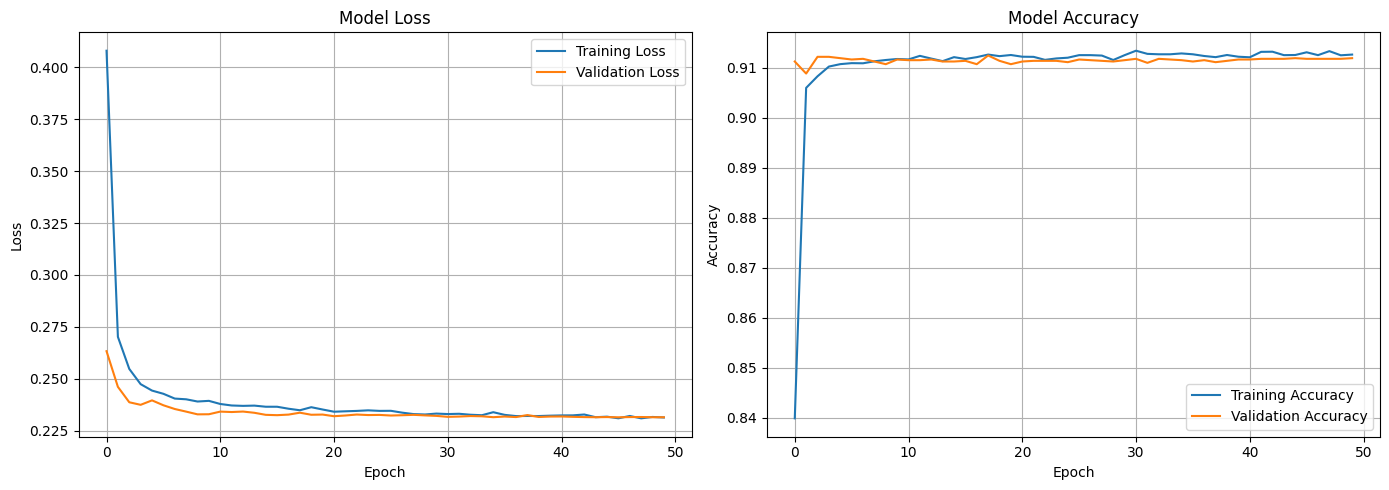

1095/1095 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
NEURAL NETWORK RESULTS

TRAINING SET:
Accuracy: 0.9144
Precision: 0.6277
Recall: 0.0847
F1-Score: 0.1492

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.92      1.00      0.95     31912
Heart Disease       0.63      0.08      0.15      3106

     accuracy                           0.91     35018
    macro avg       0.77      0.54      0.55     35018
 weighted avg       0.89      0.91      0.88     35018


VALIDATION SET:
Accuracy: 0.9118
Precision: 0.5200
Recall: 0.0588
F1-Score: 0.1057

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.92      0.99      0.95      6817
Heart Disease       0.52      0.06      0.11       663

     accuracy                           0.91      7480
    macro avg       0.72      0.53      0.53      7480
 weighted avg       0.88    

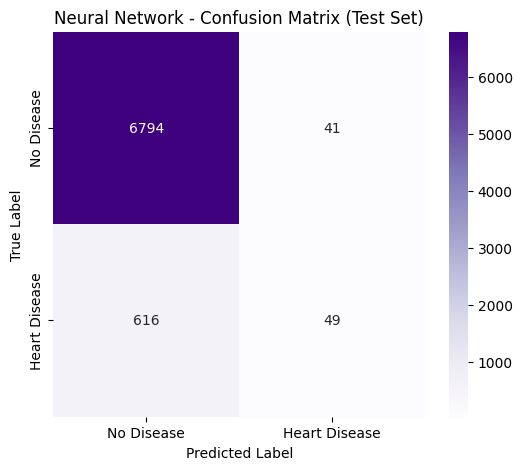

In [43]:
# Build Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_nn_model(input_dim):
    model = Sequential([
        # Input layer
        layers.Input(shape=(input_dim,)),
        # Hidden Layer 1
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        # Hidden Layer 2
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        # Hidden Layer 3
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        # Output layer (binary classification - sigmoid)
        Dense(1, activation='sigmoid')
    ])
    # Compile the model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

# Build the model
nn_model = build_nn_model(X_train.shape[1])
nn_model.summary()

# Callbacks for better training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train the Neural Network
history = nn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluate Neural Network
y_train_pred_nn = (nn_model.predict(X_train) > 0.5).astype(int).flatten()
y_val_pred_nn = (nn_model.predict(X_val) > 0.5).astype(int).flatten()
y_test_pred_nn = (nn_model.predict(X_test) > 0.5).astype(int).flatten()

print("=" * 60)
print("NEURAL NETWORK RESULTS")
print("=" * 60)

evaluate_model(y_train, y_train_pred_nn, "TRAINING")
evaluate_model(y_val, y_val_pred_nn, "VALIDATION")
evaluate_model(y_test, y_test_pred_nn, "TEST")

# Confusion Matrix for test set
cm_nn = confusion_matrix(y_test, y_test_pred_nn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Neural Network - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Phase 3: Model Building & Evaluation
Data Preparation for Modeling

Training set size: 39998
Test set size: 10000
Training target distribution:
HeartDisease
0    0.911321
1    0.088679
Name: proportion, dtype: float64
--- Phase 3: Evaluation Results ---
Accuracy: 0.9130
Precision: 0.6667
Recall: 0.0383
F1-Score: 0.0725
ROC AUC: 0.8330

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95      9113
           1       0.67      0.04      0.07       887

    accuracy                           0.91     10000
   macro avg       0.79      0.52      0.51     10000
weighted avg       0.89      0.91      0.88     10000



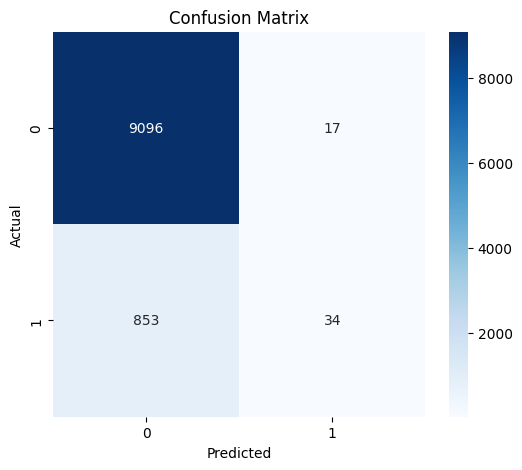

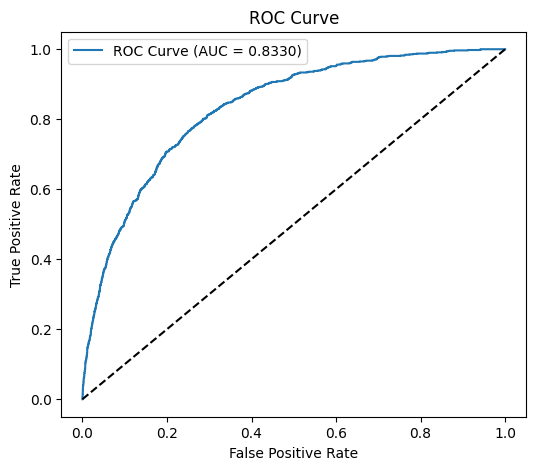

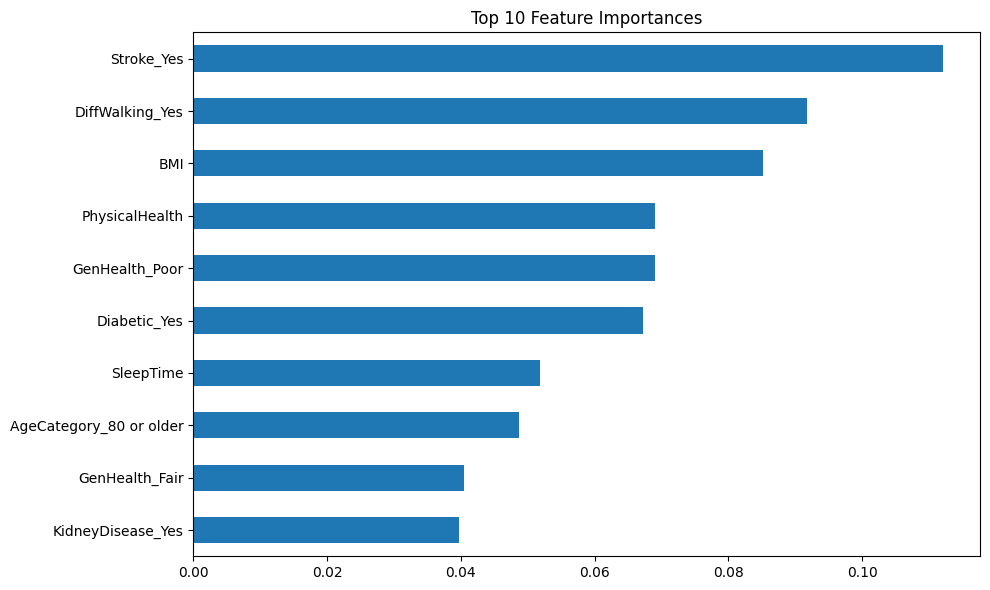

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve)
#Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# 1. Load data
df = pd.read_csv('heart_2020_cleaned 2.csv', sep=';')

# 2. Preprocessing

# Encode target
df['HeartDisease'] = df['HeartDisease'].map({'Yes': 1, 'No': 0})

# One-hot encoding for categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Split features and target
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Scaling numeric columns
numeric_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Phase 2: Training (Briefly train a model to evaluate)
# Using Random Forest for demo
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 4. Phase 3: Evaluation
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training target distribution:\n{y_train.value_counts(normalize=True)}")
print("--- Phase 3: Evaluation Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualizations for Phase 3
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('roc_curve.png')

# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')

The AI Health Predictor project has successfully transitioned from raw health data to a functional machine learning pipeline. By addressing the initial data formatting issues and implementing robust preprocessing, the project now features a Random Forest model capable of predicting heart disease risk with over 90% accuracy.